In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch import nn, optim
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import copy
import torch
import gc
import time
import os
import pickle

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

0

# Modules and Functions

## SI modules

In [120]:
# Calculates first order si
def first_order_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    mat = torch.cdist(data, data)
    _, indices = torch.topk(mat, k=2, dim=0, largest=False)
    homolabels = (labels[indices[1]] == labels)
    si = homolabels.sum() / data.shape[0]
    return si

# Calculates high order si (order=2)
def high_order_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    mat = torch.cdist(data, data)
    _, indices = torch.topk(mat, k=3, dim=0, largest=False)
    homolabels = (labels[indices[1]] == labels) * (labels[indices[2]] == labels)
    si = homolabels.sum() / data.shape[0]
    return si

# Calculates high order soft si (order=2)
def high_order_soft_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    mat = torch.cdist(data, data)
    _, indices = torch.topk(mat, k=3, dim=0, largest=False)
    homolabels = (labels[indices[1]] == labels).sum(1) + (labels[indices[2]] == labels).sum(1)
    si = homolabels.sum() / 2 / data.shape[0]
    return si

# Calculates center based si
def center_based_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    kinds_of_label = torch.unique(labels)
    centers = torch.zeros((kinds_of_label.shape[0], data.shape[1]), device=device)
    for i, label in enumerate(kinds_of_label):
        centers[i] = data[labels[:, 0] == label].mean(0)
    mat = torch.cdist(data, centers)
    _, indices = torch.topk(mat, k=1, dim=1, largest=False)
    homolabels = (kinds_of_label[indices] == labels)
    si = homolabels.sum() / data.shape[0]
    return si

# Calculates anti si (order=2)
def anti_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    mat = torch.cdist(data, data)
    _, indices = torch.topk(mat, k=3, dim=0, largest=False)
    homolabels = (labels[indices[1]] != labels) * (labels[indices[2]] != labels)
    si = homolabels.sum() / data.shape[0]
    return si

In [121]:
# The idea of this piece of code is from the following site and I modified it hugely according to my needs
# https://medium.com/the-dl/how-to-use-pytorch-hooks-5041d777f904

class VerboseExecution(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model
        # use first_input to create layer excution order once for a class instance
        self.first_input = True
        self.idx_to_name = {}
        self.name_to_idx = {}
        self.order = []
        def hook_fn(layer, _, output):
            # print(f"{layer.__name__}: {output.shape}")
            if self.first_input:
                # create layer excution order once for a class instance
                self.order.append(self.name_to_idx[layer.__name__])
            self.outputs_dict[self.name_to_idx[layer.__name__]] = output.detach()
        # Register a hook for each layer
        for i, named_module in enumerate(self.model.named_modules()):
            name, layer = named_module
            layer.__name__ = name
            self.idx_to_name[i] = name
            self.name_to_idx[name] = i
            layer.register_forward_hook(hook_fn)

    def forward(self, x):
        self.outputs_dict = {}
        x = self.model(x)
        self.first_input = False
        return x

In [122]:
# Calculate SI of output of a layer given layer number
def si_of_layer(list_of_output_dicts, total_labels, layer_num_in_order, verbose, device):
    start_time = time.time()
    key = verbose.order[layer_num_in_order]
    one_layer_outputs = torch.zeros((total_labels.shape[0],) + list_of_output_dicts[0][key].shape[1:], device=device)
    # print(one_layer_outputs.device)
    filled_rows = 0
    # print('part 1 time:', time.time() - start_time)
    for d in list_of_output_dicts:
        one_layer_outputs[filled_rows : filled_rows + d[key].shape[0]] = d[key]
        filled_rows += d[key].shape[0]
    # print('part 2 time:', time.time() - start_time)
    calculated_si = center_based_si(one_layer_outputs.reshape(total_labels.shape[0], -1), total_labels.to(device))
    # print('part 3 (si) time:', time.time() - start_time)
    del one_layer_outputs
    # print('part 4 (del) time:', time.time() - start_time)
    return calculated_si

## Ploting functions

In [123]:
# Plot input sequences in one plot
def plot_results(log_lst, logs_name ,title, xlabel, ylabel):

    if len(logs_name) != len(log_lst):
        raise ValueError('logs_name and log_lst should have same length')
    
    x = np.arange(1, len(log_lst[0])+1) # x values starting from 1
    
    for logs, logs_name in zip(log_lst, logs_name):
        # plt.plot(x,logs, label=logs_name, marker='o', markersize=3)
        plt.plot(x,logs, label=logs_name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()
    

## save and load variables

In [124]:
def save_vars(file_path, **kwargs):
  if os.path.exists(file_path):
    with open(file_path, 'wb+') as f:
        pickle.dump(kwargs, f)
  else:
    with open(file_path, 'xb+') as f:
        pickle.dump(kwargs, f)

def load_vars(file_path):
    with open(file_path, 'rb') as f:
        vars_dict = pickle.load(f)
    return vars_dict

## Calculate the number of params

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Data

In [125]:
# Load the CIFAR-10 dataset
root = '.'
download = False
cifar_dataset = datasets.CIFAR10(root=root+'/data/train', train=True, download=download, transform=None)

# Get the labels and indices for stratified split
labels = torch.Tensor(cifar_dataset.targets)
indices = torch.arange(len(labels))

# Use stratified train_test_split to get subsets
train_subset_indices, val_subset_indices = train_test_split(indices, stratify=labels, test_size=0.1, random_state=42)
_, si_train_subset_indices = train_test_split(indices, stratify=labels, test_size=0.1, random_state=40)

cifar_test_dataset = datasets.CIFAR10(root=root+'/data/test', train=False, download=download, transform=None)
test_labels = torch.Tensor(cifar_test_dataset.targets)
test_indices = torch.arange(len(test_labels))
_, si_test_subset_indices = train_test_split(test_indices, stratify=test_labels, test_size=0.1, random_state=40)

In [127]:
# Define the transformation pipelines
size_out = 32
mean = 0 # zero mean shift
std = 1
batch_size = 256
num_workers = 10
pin_memory = True
torch.manual_seed(40)
simple_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    # transforms.Resize((size_out, size_out), antialias=True),
    transforms.Normalize(mean=[mean, mean, mean], std=[std, std, std]),  # Normalize the image
])

train_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.RandomAffine(30, scale=(0.75, 1.5), translate=(0.2, 0.2), shear=15),
    transforms.RandomHorizontalFlip(),  # Flip the image horizontally with a probability of 0.5
    transforms.Normalize(mean=[mean, mean, mean], std=[std, std, std]),  # Normalize the image
    transforms.RandomResizedCrop(size=size_out, scale=(0.9, 1.1), antialias=True),
])

# Load the dataset using ImageFolder
train_dataset = Subset(
    datasets.CIFAR10(root=root+'/data/train', train=True, download=download, transform=train_transform),
    train_subset_indices)

# Create a data loader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True,
)

val_dataset = Subset(
    datasets.CIFAR10(root=root+'/data/train', train=True, download=download, transform=simple_transform),
    val_subset_indices)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True,
)


test_dataset = datasets.CIFAR10(root=root+'/data/test', train=False, download=download, transform=simple_transform)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=False,
)

si_train_dataset = Subset(
    datasets.CIFAR10(root=root+'/data/train', train=True, download=download, transform=simple_transform),
    si_train_subset_indices)

si_train_loader = torch.utils.data.DataLoader(
    si_train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=False,
)

si_test_dataset = Subset(
    datasets.CIFAR10(root=root+'/data/test', train=False, download=download, transform=simple_transform),
    si_test_subset_indices)

si_test_loader = torch.utils.data.DataLoader(
    si_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=False,
)

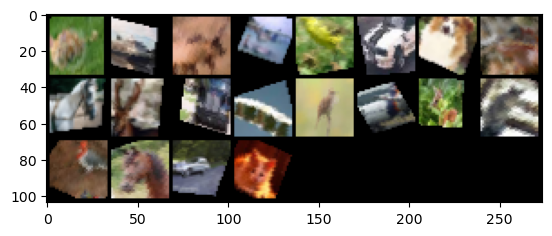

In [128]:
import torchvision.utils as vutils 
tensors = next(iter(train_loader))[0][:20] # list of pytorch tensors
grid = vutils.make_grid(tensors)
plt.imshow(grid.numpy().transpose((1, 2, 0)))
plt.show()

# Train

In [129]:
def train(model, trainloader, optimizer, criterion, device):
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        if (i + 1) % 50 == 0:
            print('iter:', i+1, end='  ')
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(f"outputs: {outputs.dtype} , labels: {labels.dtype}", outputs.shape, labels.shape)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return running_loss / len(trainloader), accuracy

In [130]:
def validate(model, val_loader, criterion, device):
    model.eval()
    actual_labels = []
    predicted_labels = []
    total_loss = 0.0
    num_batches = 0
    with torch.inference_mode():
        for i, data in enumerate(val_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            # class_weights = torch.empty((len(data[1]), 1), dtype=torch.float32)
            # for i, j in enumerate(labels):
            #     class_weights[i][0] = dict_weights[int(j.item())]
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            num_batches += 1
            predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
            predicted_labels.extend(predictions)
            actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return total_loss / num_batches, accuracy

## Custom ResNet No Normalization

In [2]:
class ResidualBlockNoNorm(nn.Module):
    def __init__(self, in_planes, planes, stride=1, skip_connection=True):
        super(ResidualBlockNoNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1),
            nn.ELU(),
            nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1)
        )
        self.add = nn.Identity()
        self.elu2 = nn.ELU()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            # print('x:\n',x,'\n\nout:',out)
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        out = self.elu2(out)
        return out
        
class CustomResNetNoNorm(nn.Module):
    def __init__(self, num_classes=10, skip_connection=True):
        super(CustomResNetNoNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockNoNorm(64, 64, skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockNoNorm(256, 256, skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [6]:
# Output shape of blocks checked to be correct 
t = CustomResNetNoNorm()
# t.load_state_dict(torch.load('models/cresnet_nonorm_skip.pt'))
t(torch.rand((5,3,32,32))).shape, count_parameters(t)

(torch.Size([5, 10]), 1710794)

In [159]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetNoNorm().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [160]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_nonorm_cp2.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/variables_cresnet_nonorm_cp2.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  
Epoch [1/100], Training loss: 2.1762, Valid loss: 2.0017, Training acc: 0.1741, Val acc: 0.2514, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [2/100], Training loss: 1.9230, Valid loss: 1.7191, Training acc: 0.2823, Val acc: 0.3682, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [3/100], Training loss: 1.7864, Valid loss: 1.6328, Training acc: 0.3365, Val acc: 0.3976, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [4/100], Training loss: 1.6754, Valid loss: 1.4429, Training acc: 0.3829, Val acc: 0.4720, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [5/100], Training loss: 1.5619, Valid loss: 1.3697, Training acc: 0.4306, Val acc: 0.4984, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [6/100], Training loss: 1.4595, Valid loss: 1.2710, Training acc: 0.4722, Va

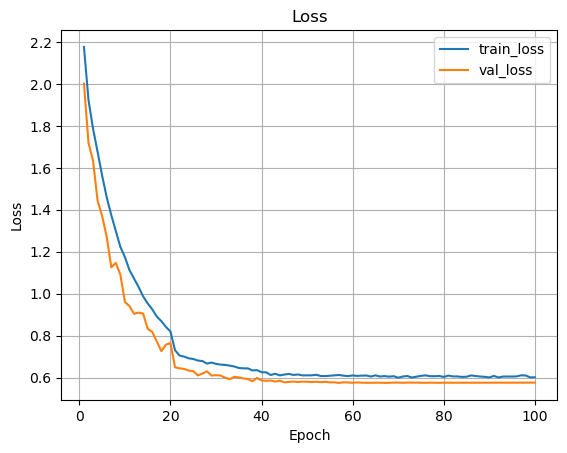

In [161]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

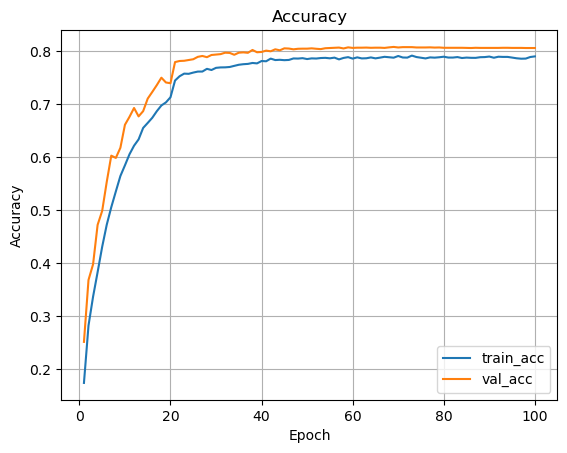

In [162]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [163]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.5746684952786094
Epoch number of best validation loss is: 56


In [164]:
checkpoint = torch.load('./models/cresnet_nonorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [165]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [166]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1000
           1       0.87      0.91      0.89      1000
           2       0.74      0.69      0.71      1000
           3       0.71      0.58      0.64      1000
           4       0.79      0.77      0.78      1000
           5       0.80      0.69      0.74      1000
           6       0.80      0.86      0.83      1000
           7       0.82      0.86      0.84      1000
           8       0.87      0.87      0.87      1000
           9       0.81      0.85      0.83      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



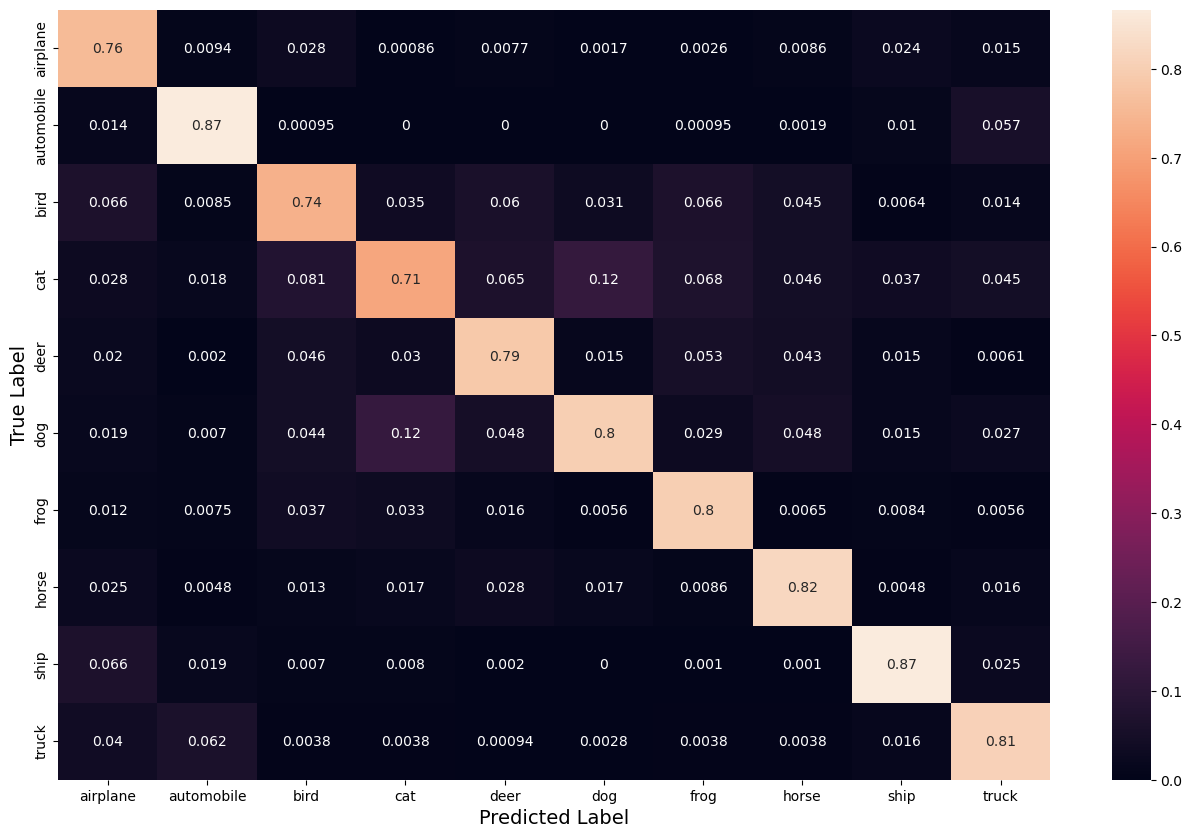

In [167]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [15]:
# make model ready for layerwised investigation
model = CustomResNetNoNorm().to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_nonorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [16]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [18]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

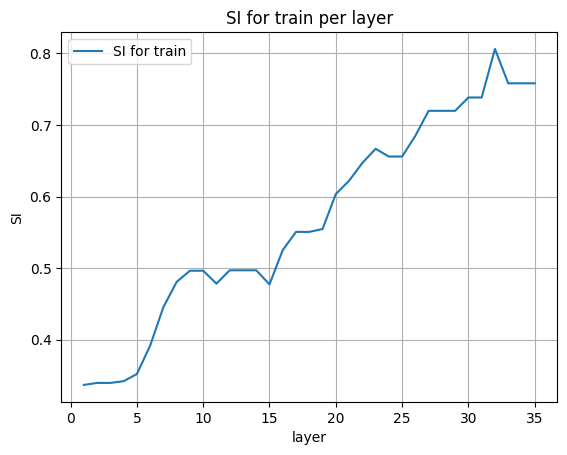

In [19]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

In [20]:
# show layer num and SI and block function for a given range of layers
for i in range(len(si_store)): 
    print('layer:', i+1,'si:', si_store[i].item())
    l_name = verbose_model.idx_to_name[verbose_model.order[i]]
    print(l_name)
    for name, item in model.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 1 si: 0.3369999825954437
block1.0
Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 2 si: 0.33980000019073486
block1.1
ELU(alpha=1.0) 

layer: 3 si: 0.33980000019073486
block1
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ELU(alpha=1.0)
) 

layer: 4 si: 0.34219998121261597
block2.0
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 5 si: 0.3522000014781952
block2.1
ELU(alpha=1.0) 

layer: 6 si: 0.3917999863624573
block2.2
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) 

layer: 7 si: 0.4456000030040741
block2.3.block1.0
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 8 si: 0.48079997301101685
block2.3.block1.1
ELU(alpha=1.0) 

layer: 9 si: 0.49639999866485596
block2.3.block1.2
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 10 si: 0.49639999866485596
block2.3.block1
Sequential(
  (0): Conv2d(64, 64, kernel_s

### SI for test data 

In [21]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [22]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

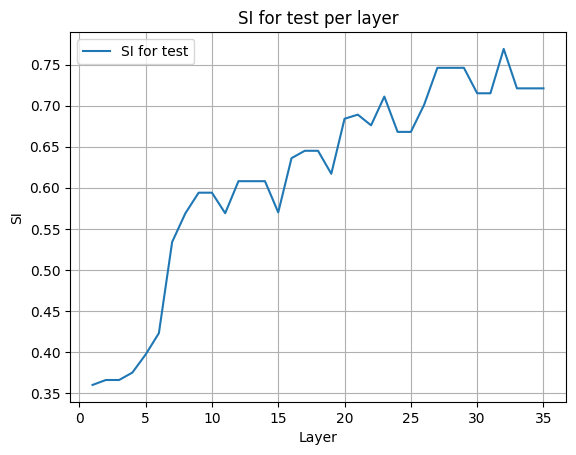

In [23]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [42]:
del list_of_output_dicts, verbose_model

In [45]:
torch.cuda.empty_cache()
gc.collect()

0

## Custom ResNet Batch Normalization

In [168]:
class ResidualBlockBatchNorm(nn.Module):
    def __init__(self, in_planes, planes, stride=1, skip_connection=True):
        super(ResidualBlockBatchNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(planes),
            nn.ELU(),
            nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(planes),
        )
        self.add = nn.Identity()
        self.elu2 = nn.ELU()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        out = self.elu2(out)
        return out
        
class CustomResNetBatchNorm(nn.Module):
    def __init__(self, num_classes=10, skip_connection=True):
        super(CustomResNetBatchNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.BatchNorm2d(32),
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockBatchNorm(64, 64, skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockBatchNorm(256, 256, skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [169]:
# Output shape of blocks checked to be correct 
t = CustomResNetBatchNorm()
t(torch.rand((5,3,32,32))).shape

torch.Size([5, 10])

In [170]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetBatchNorm().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [171]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_batchnorm_cp2.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/variables_cresnet_batchnorm_cp2.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  Train. 
Epoch [1/100], Training loss: 1.7051, Valid loss: 1.8049, Training acc: 0.3693, Val acc: 0.3951, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [2/100], Training loss: 1.4261, Valid loss: 1.4559, Training acc: 0.4851, Val acc: 0.4873, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [3/100], Training loss: 1.2952, Valid loss: 1.7185, Training acc: 0.5321, Val acc: 0.4774, lr: 0.0200000
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [4/100], Training loss: 1.2105, Valid loss: 1.1235, Training acc: 0.5687, Val acc: 0.6116, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [5/100], Training loss: 1.1446, Valid loss: 1.0158, Training acc: 0.5928, Val acc: 0.6511, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [6/100], Training loss: 1.0883, Valid loss: 1.1502,

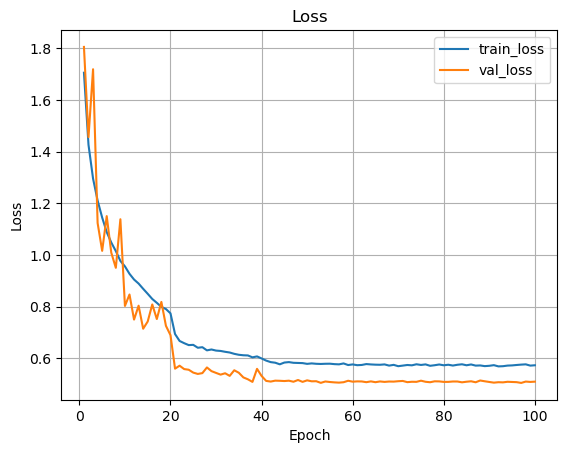

In [172]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

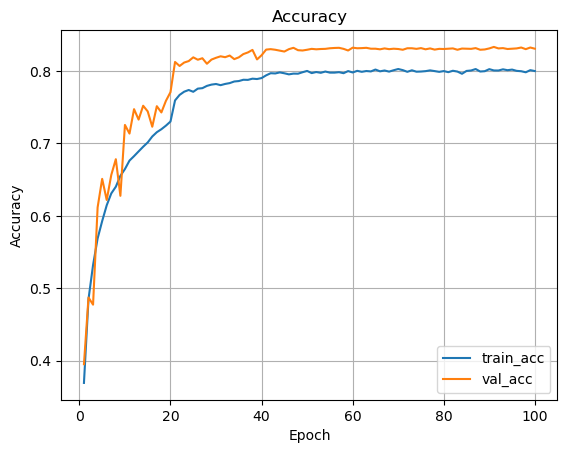

In [173]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [174]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.5046958703743784
Epoch number of best validation loss is: 96


In [175]:
checkpoint = torch.load('./models/cresnet_batchnorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [176]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
model.eval()
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [177]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.78      0.89      0.83      1000
           1       0.88      0.95      0.91      1000
           2       0.76      0.74      0.75      1000
           3       0.71      0.64      0.68      1000
           4       0.81      0.82      0.82      1000
           5       0.82      0.70      0.76      1000
           6       0.83      0.87      0.85      1000
           7       0.88      0.85      0.87      1000
           8       0.91      0.89      0.90      1000
           9       0.84      0.87      0.86      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



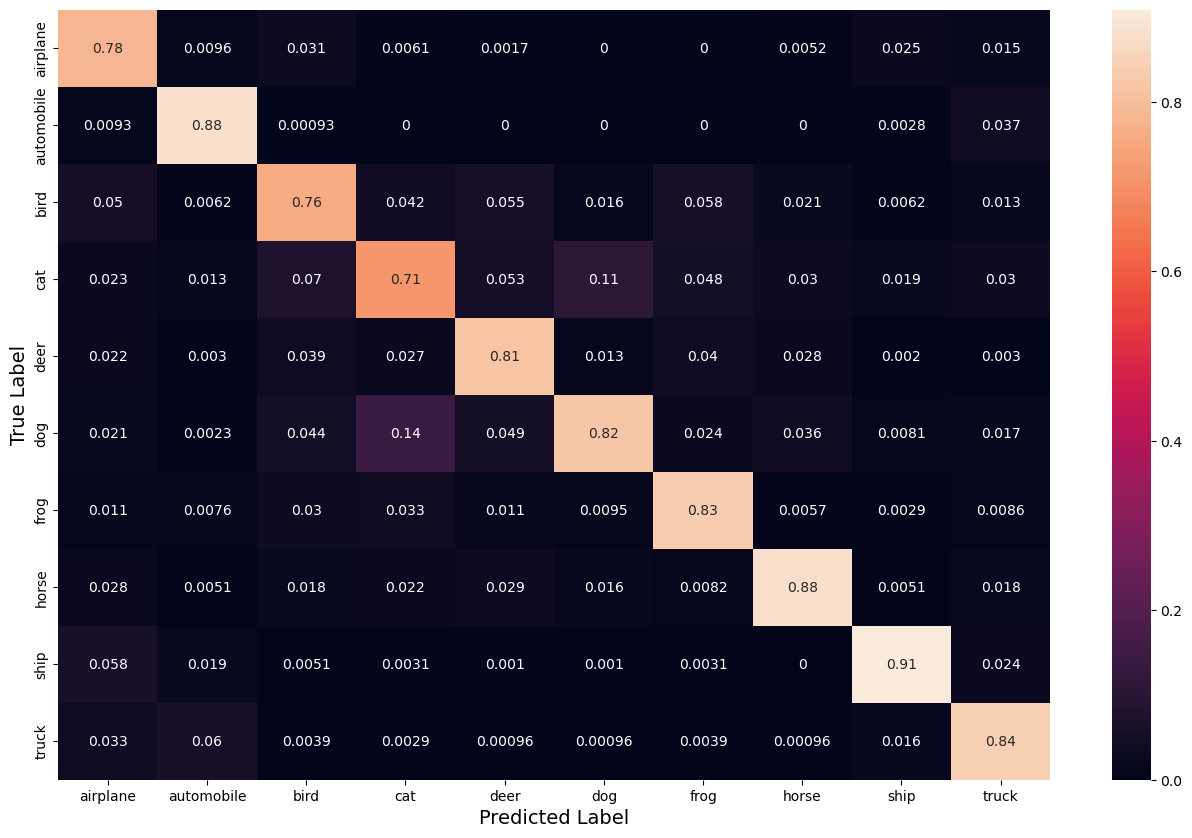

In [178]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [48]:
# make model ready for layerwised investigation
model = CustomResNetBatchNorm().to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_batchnorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [49]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))
        torch.cuda.empty_cache()
        gc.collect()

In [50]:
torch.cuda.empty_cache()
gc.collect()

0

In [51]:
! export 'PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:4'

In [ ]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
    torch.cuda.empty_cache()
    gc.collect()
#     print(i)

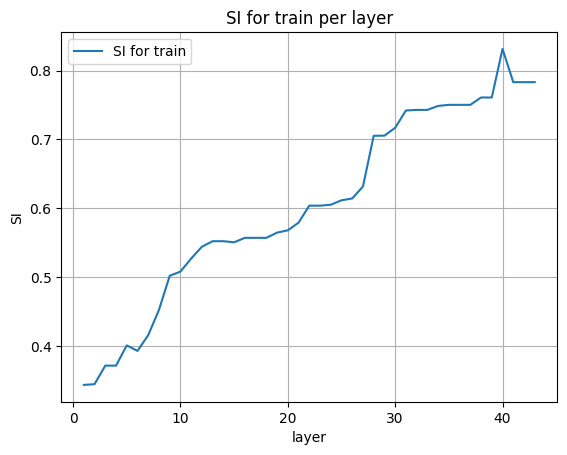

In [53]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

In [54]:
# show layer num and SI and block function for a given range of layers
for i in range(len(si_store)): 
    print('layer:', i+1,'si:', si_store[i].item())
    l_name = verbose_model.idx_to_name[verbose_model.order[i]]
    print(l_name)
    for name, item in model.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 1 si: 0.3440000116825104
block1.0
Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 2 si: 0.34511110186576843
block1.1
BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 

layer: 3 si: 0.3720000088214874
block1.2
ELU(alpha=1.0) 

layer: 4 si: 0.3720000088214874
block1
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ELU(alpha=1.0)
) 

layer: 5 si: 0.4013333320617676
block2.0
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 6 si: 0.3933333456516266
block2.1
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 

layer: 7 si: 0.4162222146987915
block2.2
ELU(alpha=1.0) 

layer: 8 si: 0.4528889060020447
block2.3
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) 

layer: 9 si: 0.5022222399711609
block2.4.block1.0
Conv2d(64, 64, k

### SI for test data 

In [55]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [56]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

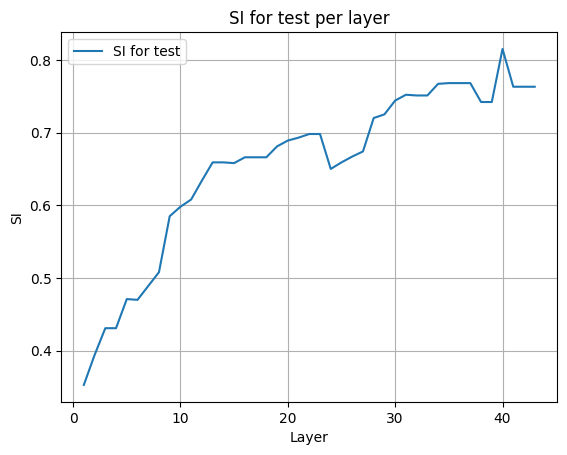

In [57]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [58]:
del list_of_output_dicts, verbose_model

In [60]:
torch.cuda.empty_cache()
gc.collect()

0

## Custom ResNet Layer Normalization

In [179]:
class ResidualBlockLayerNorm(nn.Module):
    def __init__(self, in_planes, planes, layer_normalized_shape, skip_connection=True):
        super(ResidualBlockLayerNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, planes, kernel_size=3, stride=1, padding=1),
            nn.LayerNorm(layer_normalized_shape),
            nn.ELU(),
            nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1),
            nn.LayerNorm(layer_normalized_shape),
        )
        self.add = nn.Identity()
        self.elu2 = nn.ELU()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        out = self.elu2(out)
        return out
        
class CustomResNetLayerNorm(nn.Module):
    def __init__(self, num_classes=10, skip_connection=True):
        super(CustomResNetLayerNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.LayerNorm([32, 32]),
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.LayerNorm([32, 32]),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockLayerNorm(64, 64, [16, 16], skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.BatchNorm2d(128),
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.BatchNorm2d(256),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockLayerNorm(256, 256, [4, 4], skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [180]:
# Output shape of blocks checked to be correct 
t = CustomResNetLayerNorm()
t(torch.rand((5,3,32,32))).shape

torch.Size([5, 10])

In [181]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetLayerNorm().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [182]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_layernorm_cp2.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/variables_cresnet_layernorm_cp2.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  Train. 
Epoch [1/100], Training loss: 1.6928, Valid loss: 1.4253, Training acc: 0.3830, Val acc: 0.5146, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [2/100], Training loss: 1.3619, Valid loss: 1.1000, Training acc: 0.5109, Val acc: 0.6077, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [3/100], Training loss: 1.2089, Valid loss: 1.0473, Training acc: 0.5695, Val acc: 0.6260, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [4/100], Training loss: 1.1344, Valid loss: 1.1376, Training acc: 0.6023, Val acc: 0.5987, lr: 0.0200000
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [5/100], Training loss: 1.0627, Valid loss: 0.9625, Training acc: 0.6251, Val acc: 0.6743, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [6/100], Training loss: 1.0101, Valid loss: 0.8413,

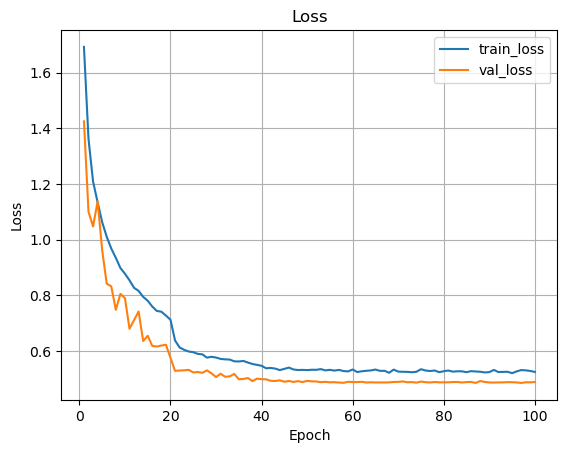

In [183]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

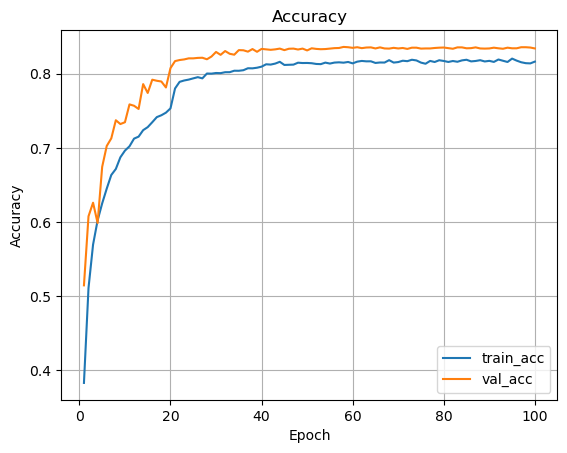

In [184]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [185]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.4846380164748744
Epoch number of best validation loss is: 86


In [186]:
checkpoint = torch.load('./models/cresnet_layernorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [187]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
model.eval()
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [188]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1000
           1       0.88      0.94      0.91      1000
           2       0.78      0.78      0.78      1000
           3       0.75      0.64      0.69      1000
           4       0.80      0.84      0.82      1000
           5       0.84      0.71      0.77      1000
           6       0.84      0.90      0.87      1000
           7       0.88      0.87      0.87      1000
           8       0.90      0.89      0.89      1000
           9       0.86      0.86      0.86      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



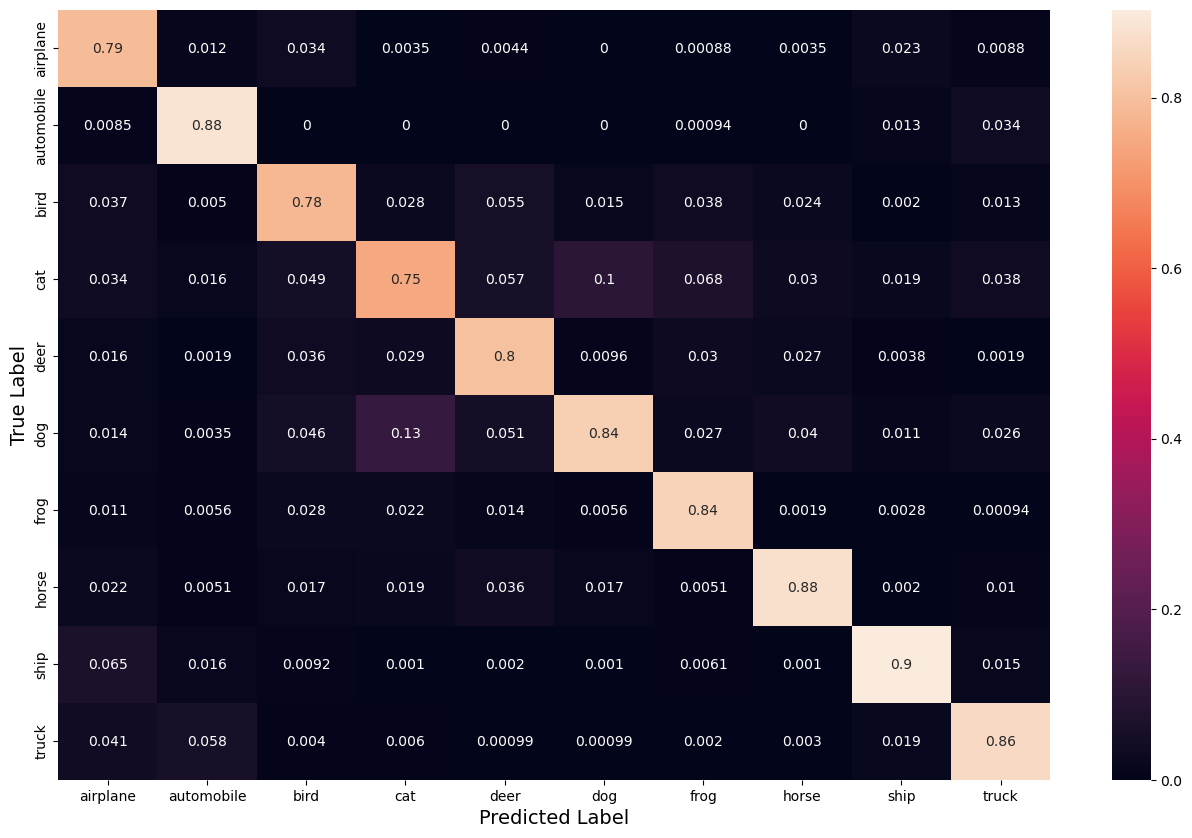

In [189]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [63]:
# make model ready for layerwised investigation
model = CustomResNetLayerNorm().to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_layernorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [64]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [65]:
torch.cuda.empty_cache()
gc.collect()

0

In [66]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

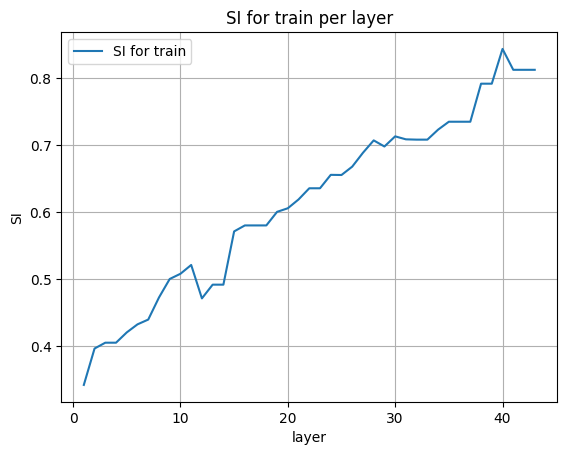

In [67]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [68]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [69]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

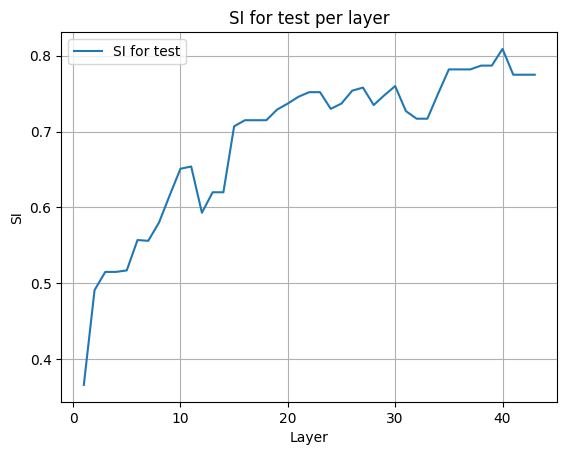

In [70]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [71]:
del list_of_output_dicts, verbose_model

In [72]:
torch.cuda.empty_cache()
gc.collect()

3449

## Custom ResNet Group Normalization

In [190]:
class ResidualBlockGroupNorm(nn.Module):
    def __init__(self, in_planes, planes, skip_connection=True):
        super(ResidualBlockGroupNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, planes, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8 ,planes),
            nn.ELU(),
            nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8 ,planes),
        )
        self.add = nn.Identity()
        self.elu2 = nn.ELU()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        out = self.elu2(out)
        return out
        
class CustomResNetGroupNorm(nn.Module):
    def __init__(self, num_classes=10, skip_connection=True):
        super(CustomResNetGroupNorm, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.GroupNorm(8 ,32),
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.GroupNorm(8 ,64),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockGroupNorm(64, 64, skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.GroupNorm(8 ,128),
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.GroupNorm(8 ,256),
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockGroupNorm(256, 256, skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [191]:
# Output shape of blocks checked to be correct 
t = CustomResNetGroupNorm()
t(torch.rand((5,3,32,32))).shape

torch.Size([5, 10])

In [192]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetGroupNorm().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [193]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_groupnorm_cp2.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/variables_cresnet_groupnorm_cp2.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  Train. 
Epoch [1/100], Training loss: 2.0467, Valid loss: 1.6732, Training acc: 0.2358, Val acc: 0.3939, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [2/100], Training loss: 1.7635, Valid loss: 1.4866, Training acc: 0.3490, Val acc: 0.4546, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [3/100], Training loss: 1.5959, Valid loss: 1.4350, Training acc: 0.4160, Val acc: 0.4829, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [4/100], Training loss: 1.4938, Valid loss: 1.3434, Training acc: 0.4596, Val acc: 0.5076, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [5/100], Training loss: 1.3821, Valid loss: 1.1649, Training acc: 0.5020, Val acc: 0.5818, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [6/100], Training loss: 1.3046, Va

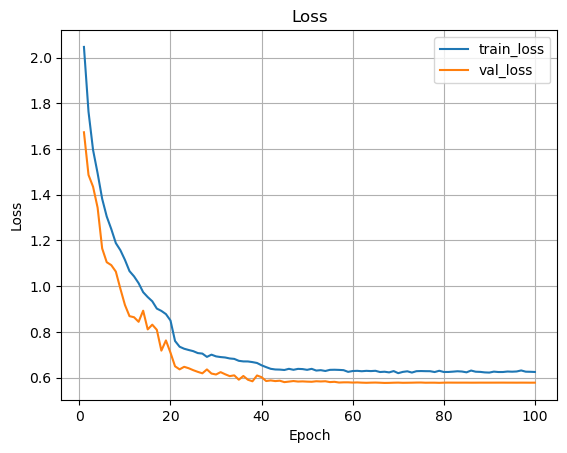

In [194]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

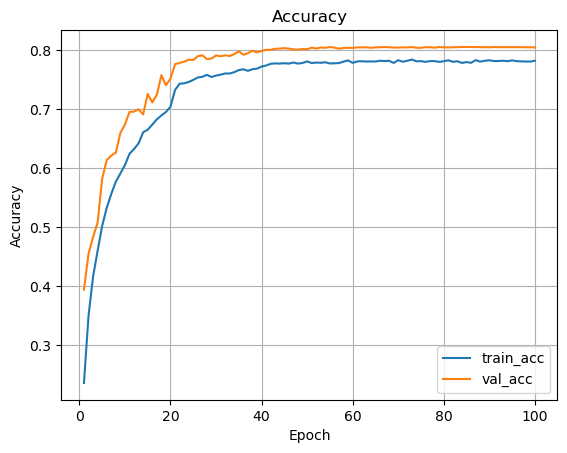

In [195]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [196]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.5764751104932082
Epoch number of best validation loss is: 66


In [197]:
checkpoint = torch.load('./models/cresnet_groupnorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [198]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
model.eval()
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [199]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.75      0.87      0.81      1000
           1       0.86      0.93      0.89      1000
           2       0.75      0.73      0.74      1000
           3       0.72      0.59      0.65      1000
           4       0.78      0.79      0.79      1000
           5       0.80      0.69      0.74      1000
           6       0.85      0.84      0.84      1000
           7       0.83      0.85      0.84      1000
           8       0.87      0.88      0.87      1000
           9       0.81      0.86      0.84      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



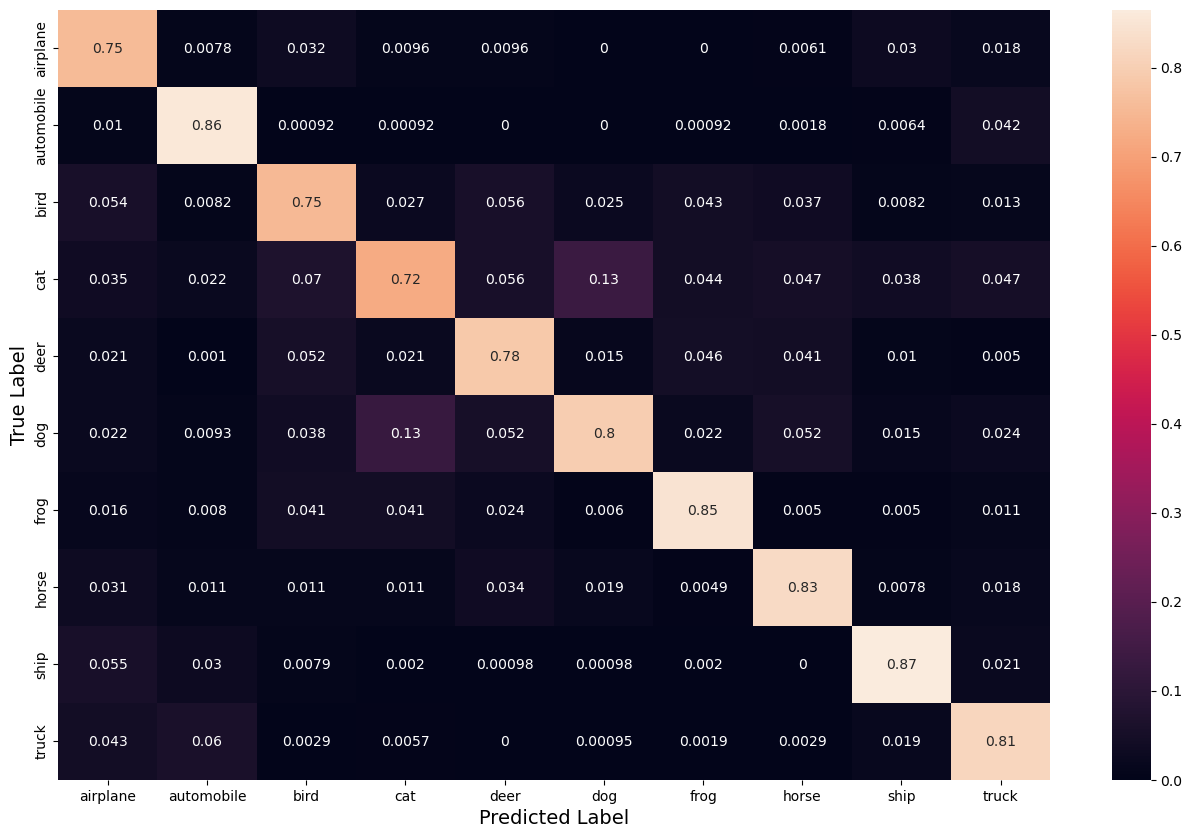

In [200]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [75]:
# make model ready for layerwised investigation
model = CustomResNetGroupNorm().to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_groupnorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [76]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [77]:
torch.cuda.empty_cache()
gc.collect()

810

In [78]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

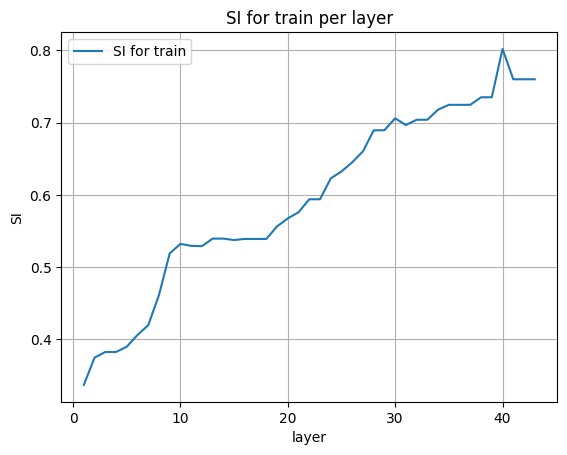

In [79]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [80]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [81]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

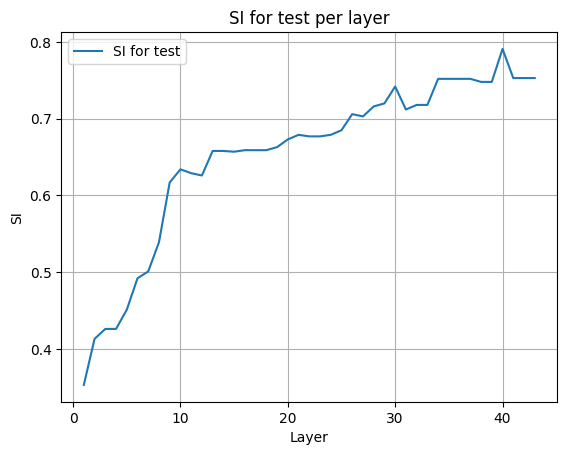

In [82]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

# Disable Skip Connections

## Custom ResNet No Normalization

In [239]:
model = CustomResNetNoNorm(skip_connection=False).to(device)
checkpoint = torch.load('./models/cresnet_nonorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [240]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [241]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.59      0.71      0.64      1000
           1       0.90      0.67      0.77      1000
           2       0.77      0.25      0.37      1000
           3       0.65      0.22      0.32      1000
           4       0.53      0.77      0.63      1000
           5       0.53      0.62      0.57      1000
           6       0.40      0.89      0.55      1000
           7       0.67      0.69      0.68      1000
           8       0.84      0.67      0.74      1000
           9       0.80      0.59      0.68      1000

    accuracy                           0.61     10000
   macro avg       0.67      0.61      0.60     10000
weighted avg       0.67      0.61      0.60     10000



### SI for train data 

In [85]:
# make model ready for layerwised investigation
model = CustomResNetNoNorm(skip_connection=False).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_nonorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [86]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [87]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

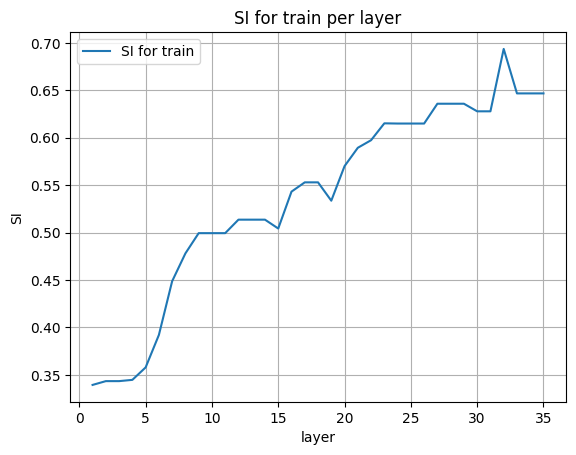

In [88]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [89]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [90]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

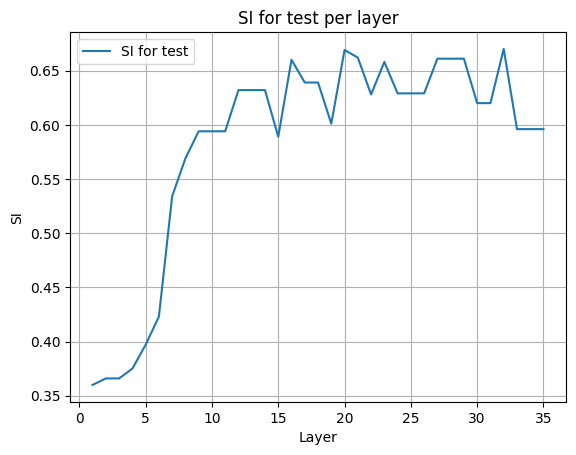

In [91]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [93]:
del list_of_output_dicts, verbose_model

In [94]:
torch.cuda.empty_cache()
gc.collect()

8109

## Custom ResNet Batch Normalization

In [242]:
model = CustomResNetBatchNorm(skip_connection=False).to(device)
checkpoint = torch.load('./models/cresnet_batchnorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [243]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [244]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.80      0.68      0.74      1000
           1       0.81      0.83      0.82      1000
           2       0.75      0.46      0.57      1000
           3       0.64      0.43      0.52      1000
           4       0.63      0.74      0.68      1000
           5       0.75      0.51      0.61      1000
           6       0.68      0.75      0.71      1000
           7       0.70      0.79      0.74      1000
           8       0.64      0.87      0.74      1000
           9       0.64      0.90      0.75      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.69     10000
weighted avg       0.71      0.70      0.69     10000



### SI for train data 

In [98]:
# make model ready for layerwised investigation
model = CustomResNetBatchNorm(skip_connection=False).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_batchnorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [99]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [100]:
torch.cuda.empty_cache()
gc.collect()

898

In [101]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

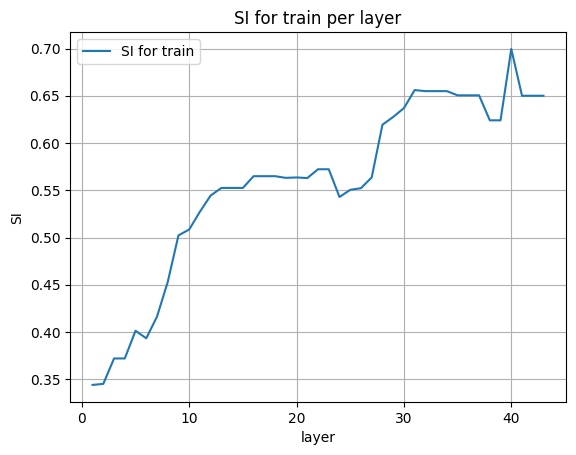

In [102]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [103]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [104]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

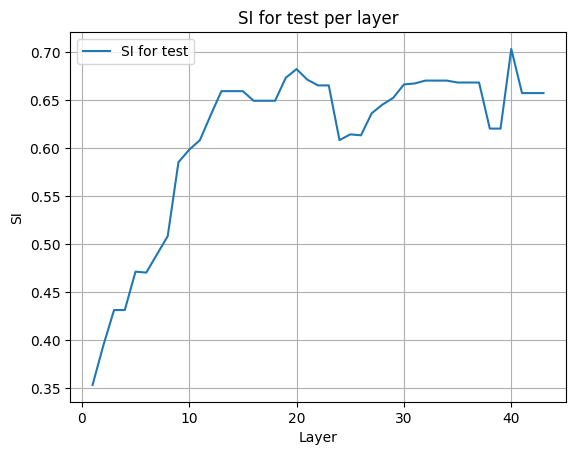

In [105]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [106]:
del list_of_output_dicts, verbose_model

In [107]:
torch.cuda.empty_cache()
gc.collect()

3766

## Custom ResNet Layer Normalization

In [245]:
model = CustomResNetLayerNorm(skip_connection=False).to(device)
checkpoint = torch.load('./models/cresnet_layernorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [246]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [247]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.38      0.12      0.18      1000
           1       0.99      0.08      0.15      1000
           2       1.00      0.01      0.01      1000
           3       0.30      0.26      0.28      1000
           4       0.43      0.48      0.45      1000
           5       0.86      0.03      0.06      1000
           6       0.23      0.82      0.36      1000
           7       0.65      0.33      0.43      1000
           8       0.32      0.71      0.44      1000
           9       0.31      0.41      0.36      1000

    accuracy                           0.32     10000
   macro avg       0.55      0.32      0.27     10000
weighted avg       0.55      0.32      0.27     10000



### SI for train data 

In [110]:
# make model ready for layerwised investigation
model = CustomResNetLayerNorm(skip_connection=False).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_layernorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [111]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [112]:
torch.cuda.empty_cache()
gc.collect()

844

In [113]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

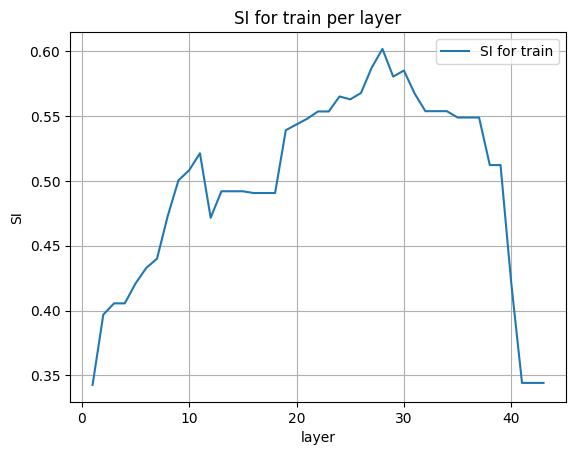

In [114]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [115]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [116]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

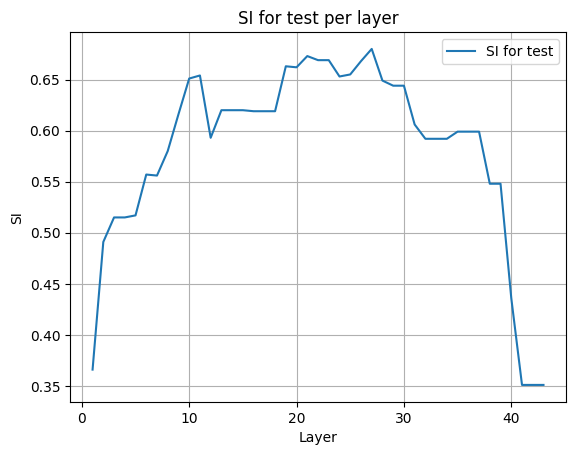

In [117]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

## Custom ResNet Group Normalization

In [248]:
model = CustomResNetGroupNorm(skip_connection=False).to(device)
checkpoint = torch.load('./models/cresnet_groupnorm_cp2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [249]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [250]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.56      0.45      0.50      1000
           1       0.78      0.59      0.67      1000
           2       0.73      0.28      0.40      1000
           3       0.46      0.17      0.24      1000
           4       0.56      0.53      0.55      1000
           5       0.95      0.02      0.04      1000
           6       0.38      0.52      0.44      1000
           7       0.71      0.51      0.59      1000
           8       0.20      0.91      0.33      1000
           9       0.93      0.18      0.30      1000

    accuracy                           0.41     10000
   macro avg       0.63      0.41      0.41     10000
weighted avg       0.63      0.41      0.41     10000



### SI for train data 

In [143]:
# make model ready for layerwised investigation
model = CustomResNetGroupNorm(skip_connection=False).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_groupnorm_cp2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [144]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [145]:
torch.cuda.empty_cache()
gc.collect()

820

In [146]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

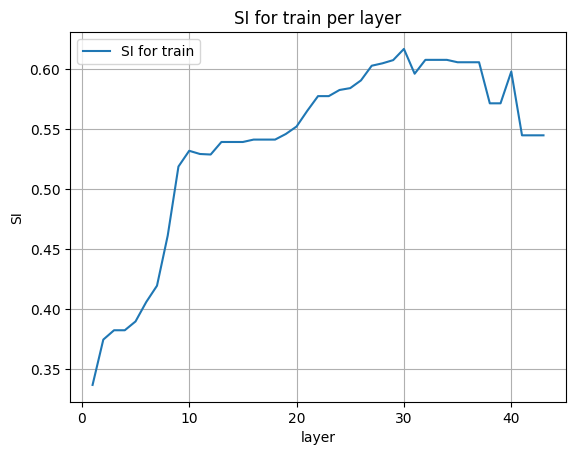

In [147]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

### SI for test data 

In [148]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [149]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

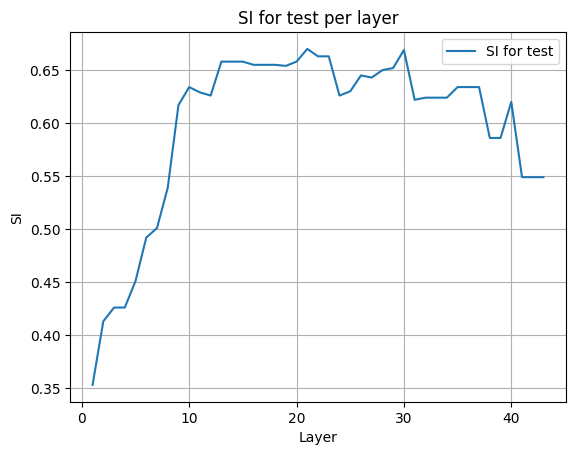

In [150]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [151]:
del list_of_output_dicts, verbose_model

In [152]:
torch.cuda.empty_cache()
gc.collect()

3656

# Change some convs with conv 1*1 in Custom ResNet No Normalization

In [7]:
class ResidualBlockNoNormChangedConvs(nn.Module):
    def __init__(self, in_planes, planes, stride=1, skip_connection=True):
        super(ResidualBlockNoNormChangedConvs, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1),
            nn.ELU(),
            nn.Conv2d(planes, planes, kernel_size=1, stride=1, padding=0)
        )
        self.add = nn.Identity()
        self.elu2 = nn.ELU()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        out = self.elu2(out)
        return out
        
class CustomResNetNoNormChangedConvs(nn.Module):
    def __init__(self, num_classes=10, skip_connection=True):
        super(CustomResNetNoNormChangedConvs, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockNoNormChangedConvs(64, 64, skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.ELU(),
            nn.MaxPool2d(2),
            ResidualBlockNoNormChangedConvs(256, 256, skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [8]:
# Output shape of blocks checked to be correct 
t = CustomResNetNoNormChangedConvs()
t(torch.rand((5,3,32,32))).shape, count_parameters(t)

(torch.Size([5, 10]), 1153738)

In [204]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetNoNormChangedConvs().to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [205]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_nonorm_conv1.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/variables_cresnet_nonorm_conv1.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  
Epoch [1/100], Training loss: 2.1810, Valid loss: 2.0117, Training acc: 0.1702, Val acc: 0.2508, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [2/100], Training loss: 1.9743, Valid loss: 1.8000, Training acc: 0.2592, Val acc: 0.3382, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [3/100], Training loss: 1.8344, Valid loss: 1.7002, Training acc: 0.3175, Val acc: 0.3682, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [4/100], Training loss: 1.7400, Valid loss: 1.5043, Training acc: 0.3549, Val acc: 0.4529, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [5/100], Training loss: 1.6224, Valid loss: 1.4419, Training acc: 0.4073, Val acc: 0.4688, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  
Epoch [6/100], Training loss: 1.5256, Valid loss: 1.3706, Training acc: 0.4469, Va

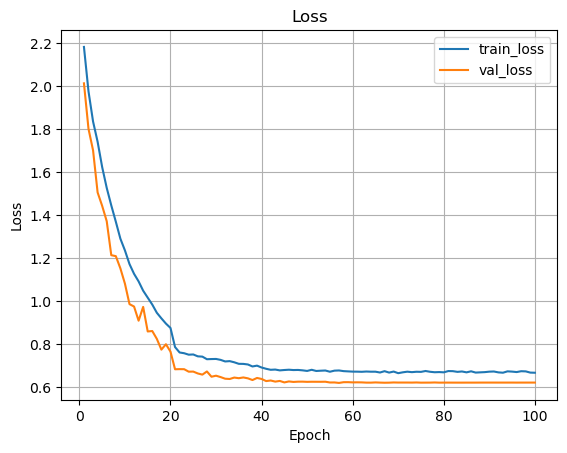

In [206]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

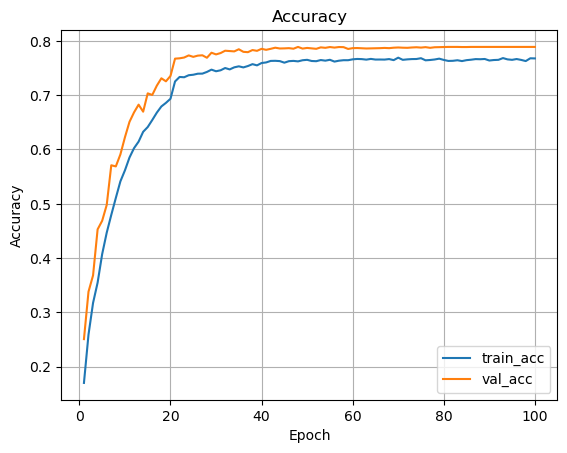

In [207]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [208]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.6186273160733675
Epoch number of best validation loss is: 56


In [209]:
checkpoint = torch.load('./models/cresnet_nonorm_conv1.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [210]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []

# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [211]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.75      0.87      0.81      1000
           1       0.87      0.91      0.89      1000
           2       0.72      0.70      0.71      1000
           3       0.71      0.56      0.63      1000
           4       0.76      0.77      0.77      1000
           5       0.77      0.64      0.70      1000
           6       0.81      0.86      0.83      1000
           7       0.82      0.84      0.83      1000
           8       0.86      0.88      0.87      1000
           9       0.79      0.85      0.82      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000



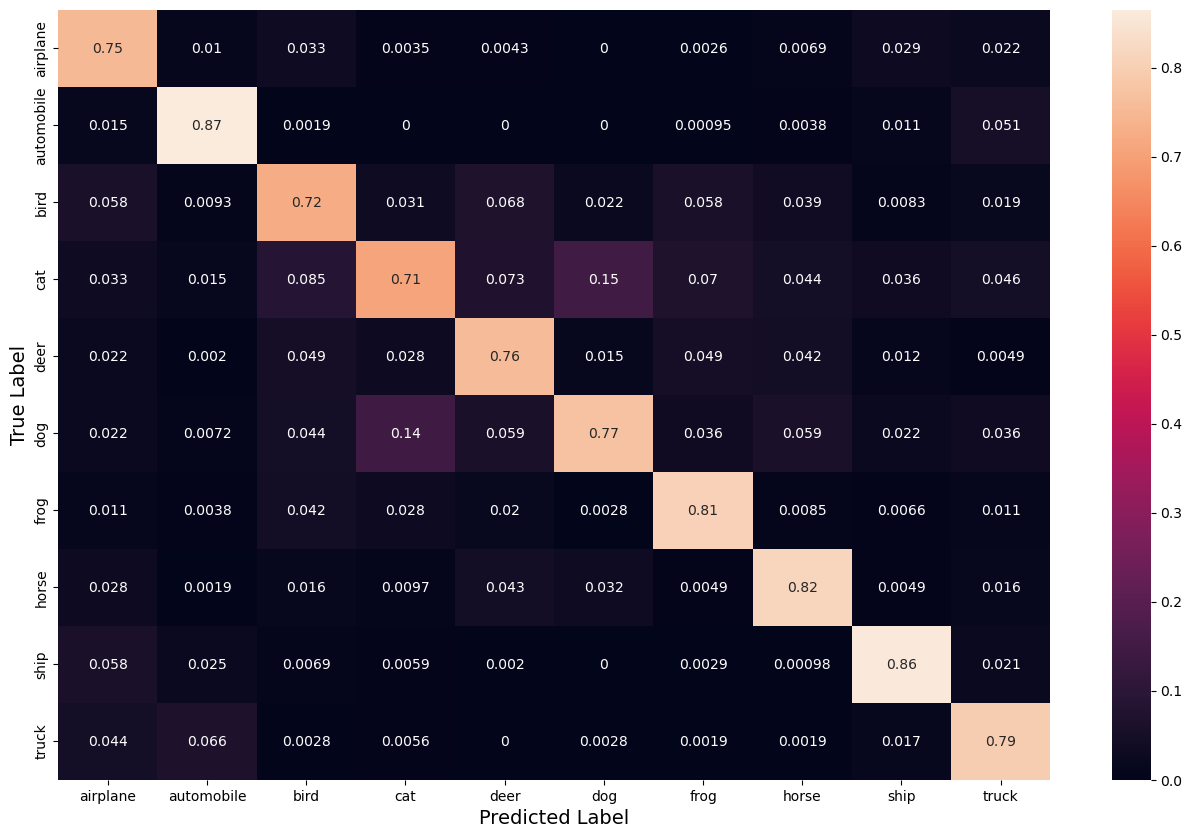

In [212]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [155]:
# make model ready for layerwised investigation
model = CustomResNetNoNormChangedConvs().to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_nonorm_conv1.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [156]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [157]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

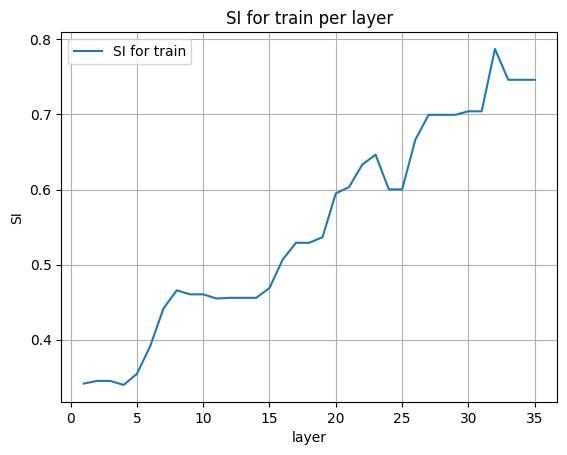

In [158]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

In [159]:
# show layer num and SI and block function for a given range of layers
for i in range(len(si_store)): 
    print('layer:', i+1,'si:', si_store[i].item())
    l_name = verbose_model.idx_to_name[verbose_model.order[i]]
    print(l_name)
    for name, item in model.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 1 si: 0.34155556559562683
block1.0
Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 2 si: 0.34511110186576843
block1.1
ELU(alpha=1.0) 

layer: 3 si: 0.34511110186576843
block1
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ELU(alpha=1.0)
) 

layer: 4 si: 0.33977776765823364
block2.0
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 5 si: 0.3544444441795349
block2.1
ELU(alpha=1.0) 

layer: 6 si: 0.3911111056804657
block2.2
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) 

layer: 7 si: 0.4413333237171173
block2.3.block1.0
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 8 si: 0.46577778458595276
block2.3.block1.1
ELU(alpha=1.0) 

layer: 9 si: 0.46044445037841797
block2.3.block1.2
Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1)) 

layer: 10 si: 0.46044445037841797
block2.3.block1
Sequential(
  (0): Conv2d(64, 64, kernel_size=(3, 3), str

### SI for test data 

In [160]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [161]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

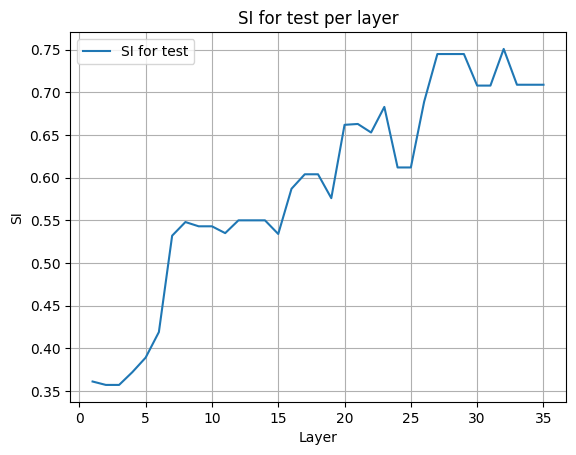

In [162]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [93]:
del list_of_output_dicts, verbose_model

In [94]:
torch.cuda.empty_cache()
gc.collect()

8109

# Use Grouped Conv in Custom ResNet

In [11]:
class GroupedConv(nn.Module):
    def __init__(self, in_planes, groups, skip_connection=True):
        super(GroupedConv, self).__init__()
        self.skip_connection = skip_connection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_planes, int(in_planes/2), kernel_size=1, stride=1, padding=0),
            nn.Conv2d(int(in_planes/2), int(in_planes/2), kernel_size=3, stride=1, padding=1, groups=groups),
            nn.Conv2d(int(in_planes/2), in_planes, kernel_size=1, stride=1, padding=0)
        )
        self.add = nn.Identity()
    def forward(self, x):
        out = self.block1(x)
        if self.skip_connection:
            out = torch.add(out, x)
        out = self.add(out) # getting add production as an output
        return out
        
class CustomResNetNoNormGroupedConv(nn.Module):
    def __init__(self, groups, num_classes=10, skip_connection=True):
        super(CustomResNetNoNormGroupedConv, self).__init__()
        self.skip_connection = skip_connection
        self.groups = groups
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # ID=1
            nn.ELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # ID=3
            nn.ELU(),
            nn.MaxPool2d(2),
            GroupedConv(64, self.groups, skip_connection=self.skip_connection)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # ID=11
            nn.ELU(),
            nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # ID=14
            nn.ELU(),
            nn.MaxPool2d(2),
            GroupedConv(256, self.groups, skip_connection=self.skip_connection)
        )
        self.avgpool = nn.AvgPool2d(3) # ID=22
        self.flatten = nn.Flatten() # ID=23
        self.fc = nn.Sequential(
            nn.Linear(256, 256), # ID=24
            nn.Linear(256, num_classes)
        )
        self.softmax = nn.Softmax(-1)
    def forward(self, x):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

In [13]:
# Output shape of blocks checked to be correct 
t = CustomResNetNoNormGroupedConv(groups=2)
# t.load_state_dict(torch.load('models/cresnet_nonorm_skip.pt'))
t(torch.rand((5,3,32,32))).shape, count_parameters(t)

(torch.Size([5, 10]), 605386)

## groups = 2

In [221]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetNoNormGroupedConv(groups=2).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [222]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_groupconv2.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/cresnet_groupconv2.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  Train. 
Epoch [1/100], Training loss: 2.2035, Valid loss: 2.0516, Training acc: 0.1594, Val acc: 0.2366, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [2/100], Training loss: 2.0007, Valid loss: 1.8134, Training acc: 0.2506, Val acc: 0.3306, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [3/100], Training loss: 1.8586, Valid loss: 1.7131, Training acc: 0.3068, Val acc: 0.3705, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [4/100], Training loss: 1.7758, Valid loss: 1.5705, Training acc: 0.3433, Val acc: 0.4190, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [5/100], Training loss: 1.6852, Valid loss: 1.5152, Training acc: 0.3822, Val acc: 0.4272, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [6/100], Training loss: 1.5968, Va

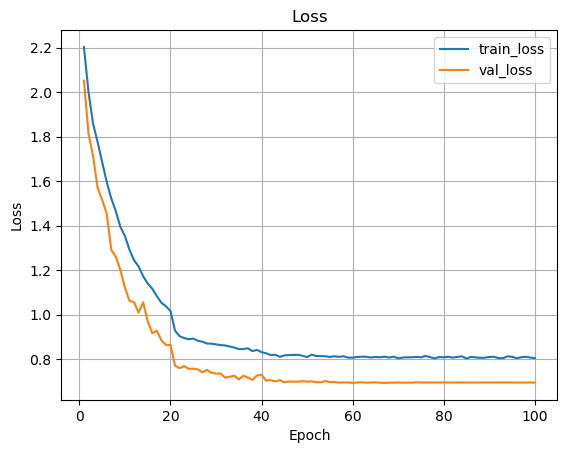

In [223]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

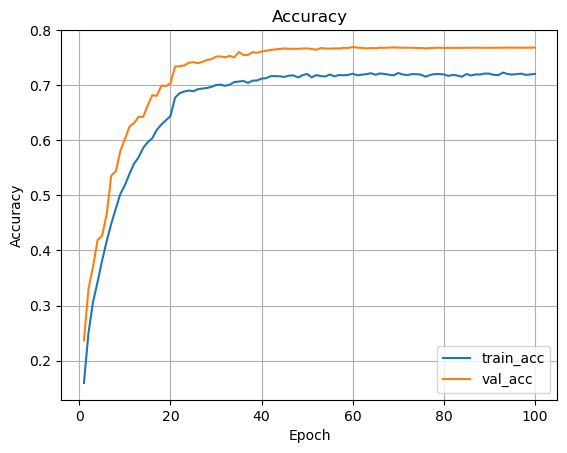

In [224]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [225]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.692843098389475
Epoch number of best validation loss is: 59


In [226]:
checkpoint = torch.load('./models/cresnet_groupconv2.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [227]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
model.eval()
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [228]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.73      0.85      0.78      1000
           1       0.85      0.90      0.87      1000
           2       0.71      0.65      0.68      1000
           3       0.68      0.49      0.57      1000
           4       0.73      0.75      0.74      1000
           5       0.73      0.65      0.69      1000
           6       0.78      0.81      0.79      1000
           7       0.78      0.81      0.79      1000
           8       0.85      0.86      0.86      1000
           9       0.75      0.83      0.79      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



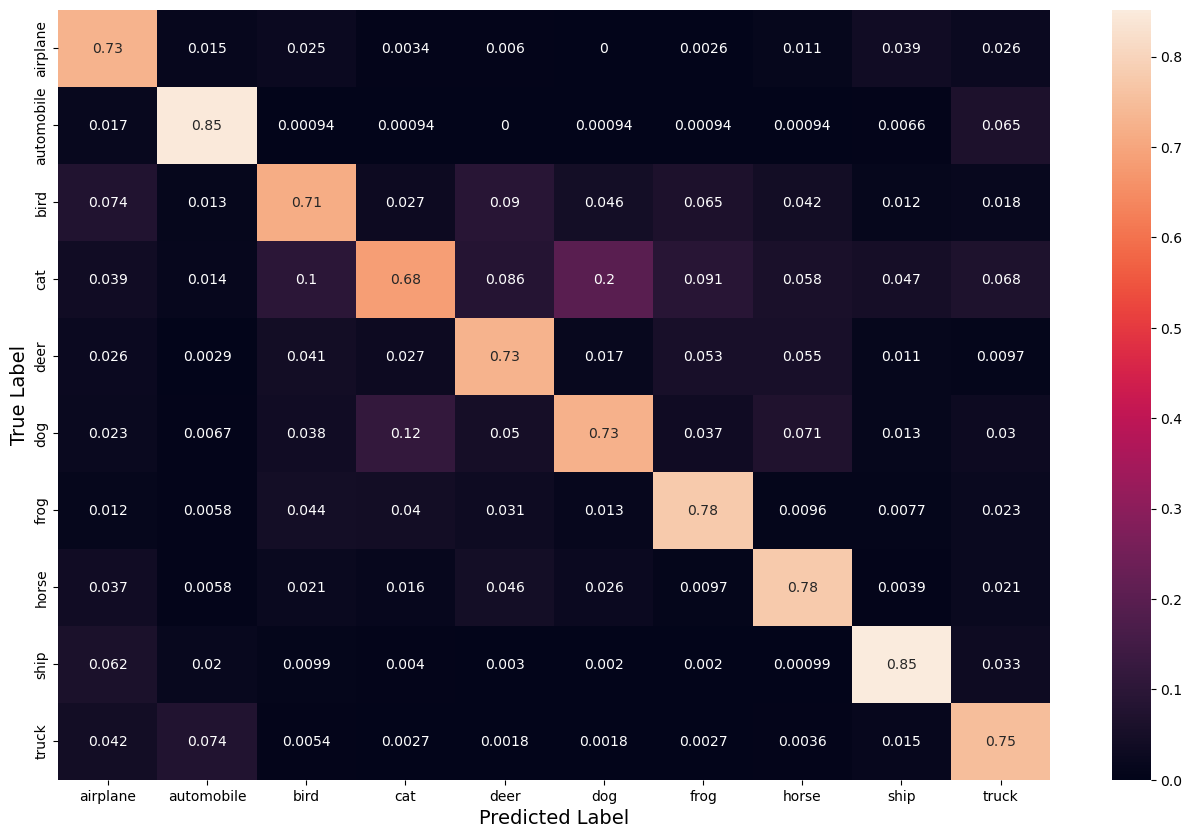

In [229]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [166]:
# make model ready for layerwised investigation
model = CustomResNetNoNormGroupedConv(groups=2).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_groupconv2.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [167]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [168]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

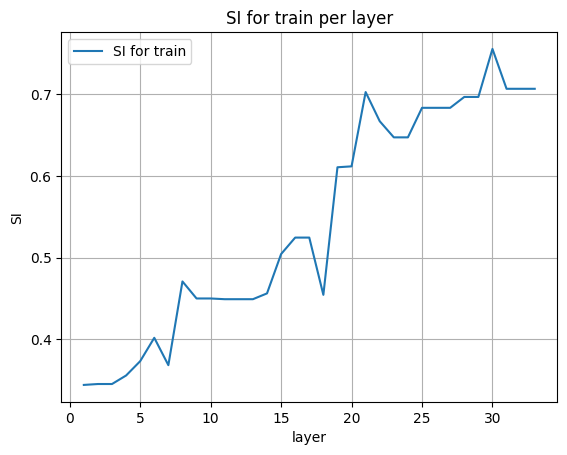

In [169]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

In [170]:
# show layer num and SI and block function for a given range of layers
for i in range(len(si_store)): 
    print('layer:', i+1,'si:', si_store[i].item())
    l_name = verbose_model.idx_to_name[verbose_model.order[i]]
    print(l_name)
    for name, item in model.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 1 si: 0.34377777576446533
block1.0
Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 2 si: 0.3448888957500458
block1.1
ELU(alpha=1.0) 

layer: 3 si: 0.3448888957500458
block1
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ELU(alpha=1.0)
) 

layer: 4 si: 0.3553333282470703
block2.0
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 5 si: 0.3728888928890228
block2.1
ELU(alpha=1.0) 

layer: 6 si: 0.4015555679798126
block2.2
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) 

layer: 7 si: 0.36800000071525574
block2.3.block1.0
Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1)) 

layer: 8 si: 0.47066667675971985
block2.3.block1.1
Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=2) 

layer: 9 si: 0.4497777819633484
block2.3.block1.2
Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1)) 

layer: 10 si: 0.4497777819633484
block2.3.block1
Sequential(
  (0

### SI for test data 

In [171]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [172]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

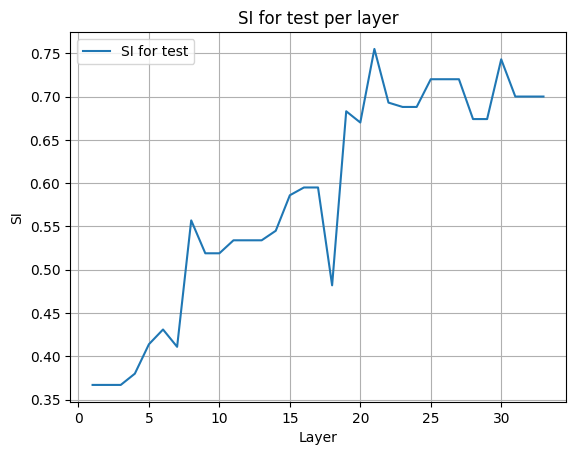

In [173]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

## groups = 4

In [16]:
# Output shape of blocks checked to be correct 
t = CustomResNetNoNormGroupedConv(groups=4)
# t.load_state_dict(torch.load('models/cresnet_nonorm_skip.pt'))
t(torch.rand((5,3,32,32))).shape, count_parameters(t)

(torch.Size([5, 10]), 566218)

In [230]:
lr = 0.02
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = CustomResNetNoNormGroupedConv(groups=4).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
epoch_counter = 0
epoch_total = 0
# loss_prev = 99999999 #initialized as inf 
min_val_loss = 99999999 #initialized as inf

In [231]:
num_epochs = 100
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )


for epoch in range(num_epochs):
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_acc[epoch_counter] = tmp_metrics
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_acc[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training acc: {:.4f}, Val acc: {:.4f}, lr: {:.7f}'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_acc[epoch_counter], 
                   val_acc[epoch_counter], scheduler.get_last_lr()[0]))
    
    # if (loss_prev < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.Adam(model.parameters(), lr=lr)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/cresnet_groupconv4.pt')
        print('state dict saved')
        min_val_loss = val_loss[epoch_counter]
    epoch_counter += 1
    scheduler.step()
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_acc' : train_acc[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_acc' : val_acc[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        'lr' : scheduler.get_last_lr()[0],
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved')
    model = model.to(device)
    save_vars('./tmp/cresnet_groupconv4.pkl', **tmp)
    torch.cuda.empty_cache()
    gc.collect()

iter: 50  iter: 100  iter: 150  Train. 
Epoch [1/100], Training loss: 2.2028, Valid loss: 2.0429, Training acc: 0.1602, Val acc: 0.2519, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [2/100], Training loss: 2.0039, Valid loss: 1.8179, Training acc: 0.2487, Val acc: 0.3316, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [3/100], Training loss: 1.8577, Valid loss: 1.7060, Training acc: 0.3052, Val acc: 0.3694, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [4/100], Training loss: 1.7694, Valid loss: 1.5634, Training acc: 0.3463, Val acc: 0.4365, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [5/100], Training loss: 1.6862, Valid loss: 1.5416, Training acc: 0.3826, Val acc: 0.4319, lr: 0.0200000
state dict saved
variables saved
iter: 50  iter: 100  iter: 150  Train. 
Epoch [6/100], Training loss: 1.6032, Va

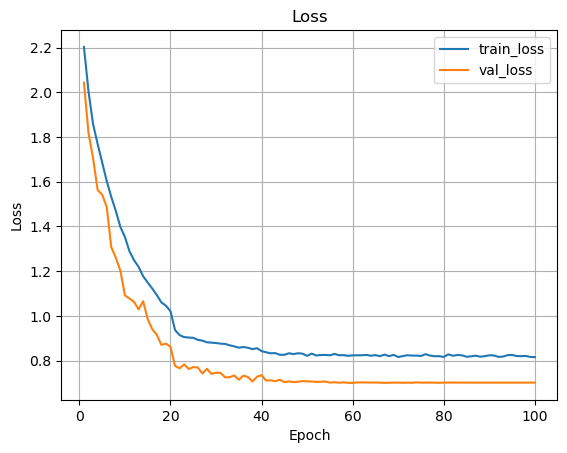

In [232]:
plot_results([train_loss, val_loss], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

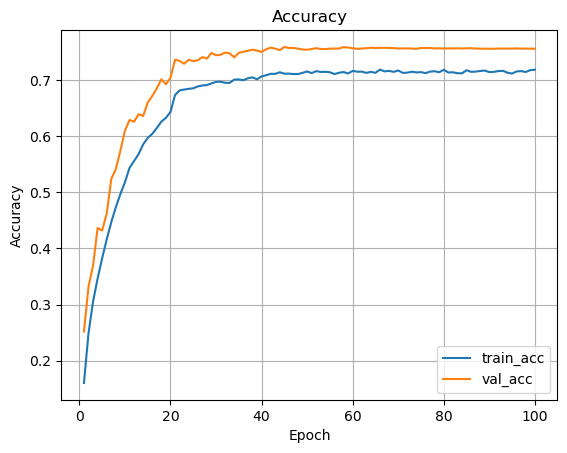

In [233]:
plot_results([train_acc, val_acc], ['train_acc', 'val_acc'], 'Accuracy', 'Epoch', 'Accuracy')

In [234]:
# best validation loss and epoch number of that
look_after_epoch = 1
best_val_loss = min(val_loss[look_after_epoch-1: ])
best_epoch = val_loss[look_after_epoch-1: ].argmin() + look_after_epoch - 1
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch}')

Best validation loss is: 0.7000773454967298
Epoch number of best validation loss is: 59


In [235]:
checkpoint = torch.load('./models/cresnet_groupconv4.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [236]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
model.eval()
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())

In [237]:
# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.71      0.84      0.77      1000
           1       0.85      0.89      0.87      1000
           2       0.72      0.62      0.67      1000
           3       0.67      0.49      0.57      1000
           4       0.73      0.74      0.74      1000
           5       0.74      0.64      0.69      1000
           6       0.75      0.83      0.79      1000
           7       0.76      0.80      0.78      1000
           8       0.83      0.86      0.85      1000
           9       0.75      0.84      0.79      1000

    accuracy                           0.76     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.75      0.76      0.75     10000



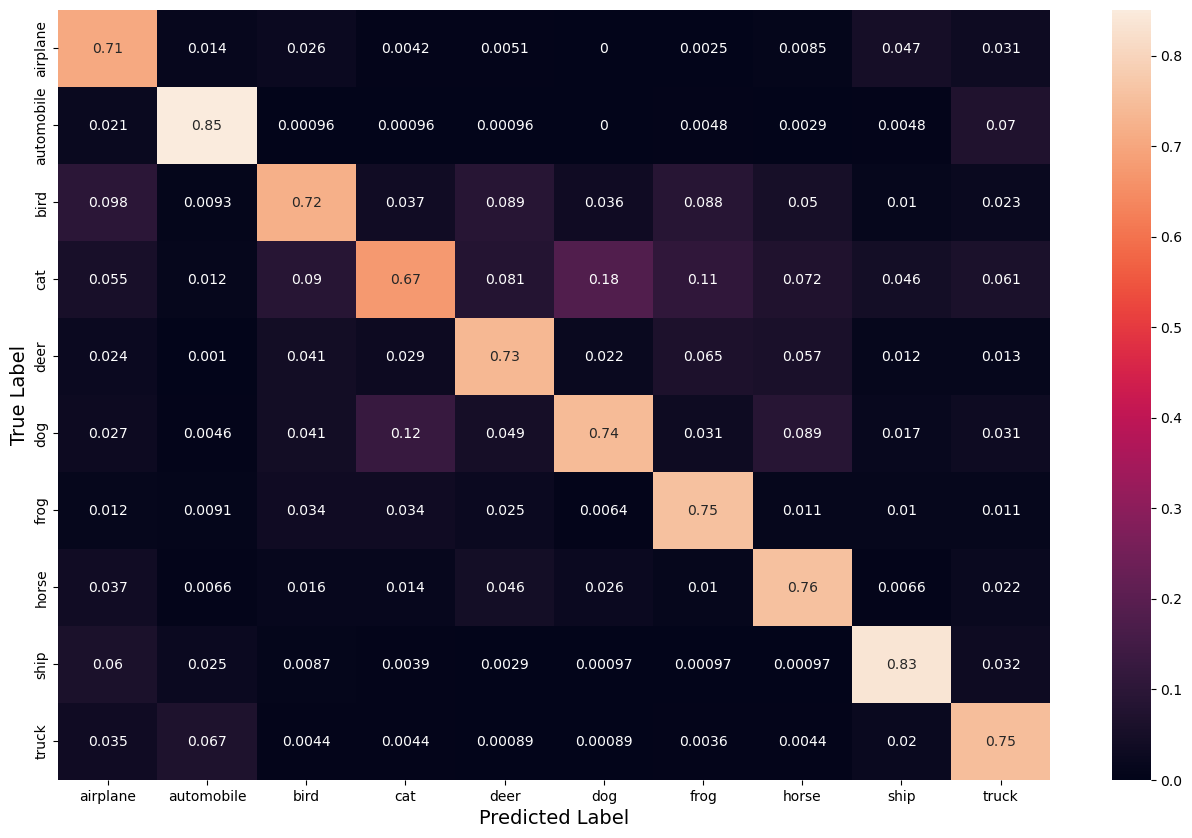

In [238]:
import seaborn as sn
import pandas as pd
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=0)[:, None],
                     index = test_dataset.classes, columns = test_dataset.classes, )
plt.figure(figsize = (16,10))
sn.heatmap(df_cm, annot=True, )
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

### SI for train data 

In [178]:
# make model ready for layerwised investigation
model = CustomResNetNoNormGroupedConv(groups=4).to(device)
checkpoint = torch.load('/kaggle/input/models-3/cresnet_groupconv4.pt')
model.load_state_dict(checkpoint)
verbose_model = VerboseExecution(model)

In [179]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [180]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

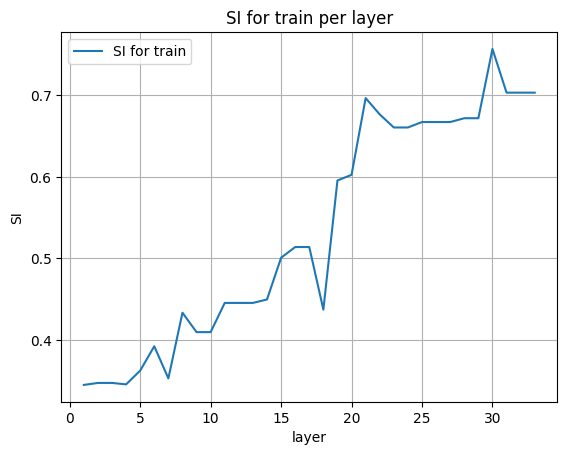

In [181]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

In [182]:
# show layer num and SI and block function for a given range of layers
for i in range(len(si_store)): 
    print('layer:', i+1,'si:', si_store[i].item())
    l_name = verbose_model.idx_to_name[verbose_model.order[i]]
    print(l_name)
    for name, item in model.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 1 si: 0.34511110186576843
block1.0
Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 2 si: 0.347555547952652
block1.1
ELU(alpha=1.0) 

layer: 3 si: 0.347555547952652
block1
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ELU(alpha=1.0)
) 

layer: 4 si: 0.3457777798175812
block2.0
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 

layer: 5 si: 0.36266666650772095
block2.1
ELU(alpha=1.0) 

layer: 6 si: 0.3924444615840912
block2.2
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) 

layer: 7 si: 0.3531111180782318
block2.3.block1.0
Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1)) 

layer: 8 si: 0.43355557322502136
block2.3.block1.1
Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=4) 

layer: 9 si: 0.40977779030799866
block2.3.block1.2
Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1)) 

layer: 10 si: 0.40977779030799866
block2.3.block1
Sequential(
  (0

### SI for test data 

In [183]:
# give inputs to verbose model and it will save every layer outputs 
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_model.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_model(data.to(device))
        list_of_output_dicts.append(verbose_model.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [184]:
# store SI of outputs of every layer
si_store = torch.zeros(len(verbose_model.order), device=device)
for i in range(len(verbose_model.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_model, device)
    si_store[i] = layer_si
#     print(i)

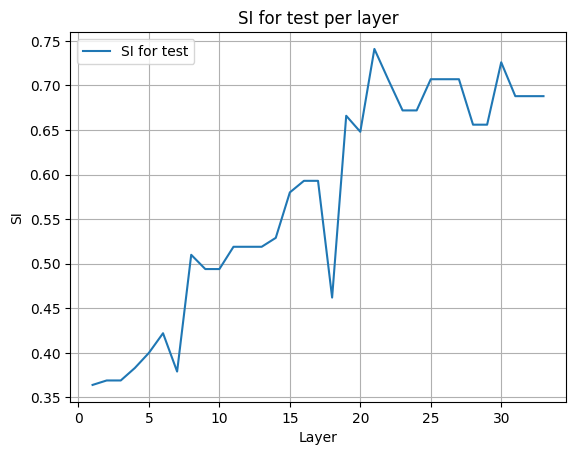

In [185]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'Layer', 'SI')

In [186]:
del list_of_output_dicts, verbose_model

In [187]:
torch.cuda.empty_cache()
gc.collect()

8249

# Sandbox

In [170]:
sample_layer = nn.BatchNorm1d((3))
sample_layer.bias.shape, sample_layer(torch.rand((5,3))).shape

(torch.Size([3]), torch.Size([5, 3]))

In [160]:
sample_layer = nn.LayerNorm((32, 32))
sample_layer.bias.shape, sample_layer(torch.rand((5,3,32,32))).shape

(torch.Size([32, 32]), torch.Size([5, 3, 32, 32]))

In [164]:
sample_layer = nn.BatchNorm2d((3))
sample_layer.bias.shape, sample_layer(torch.rand((5,3,32,32))).shape

(torch.Size([3]), torch.Size([5, 3, 32, 32]))

In [173]:
sample_layer = nn.LayerNorm((3,3))
sample_layer.bias.shape, sample_layer(torch.rand((5,32,3,3))).shape

(torch.Size([3, 3]), torch.Size([5, 32, 3, 3]))

In [191]:
sample_layer = nn.GroupNorm(2,128)
sample_layer.bias.shape, sample_layer(torch.rand((5,128,32,32))).shape

(torch.Size([128]), torch.Size([5, 128, 32, 32]))